# 02 — Build a two-layer ocean and test an effective carbon pump

In 01, adding the inferred TA allowed a uniform ocean to recover the reference
state. Here you divide that ocean into surface and deep layers, then introduce
a downward carbon transfer to maintain a DIC difference between them.

**Learning goals:** check that adding a reservoir conserves carbon and TA;
explain a maintained DIC gradient as a balance between pump and mixing;
calculate a finite carbon input and verify its inventory.

**Core time: 55 minutes.** Follow the same predict → map → run → check → explain
sequence as in 01.

| Part | Main question | Time |
| --- | --- | --- |
| A. Add the deep box | Does the two-layer model recover the buffered 01 equilibrium without a pump? | 20 min |
| B. Add the effective pump | What pump coefficient maintains the reference DIC ratio? | 20 min |
| C. Add carbon | How much carbon allows the pumped model to reach the full reference state? | 15 min |

Part B follows a <mark style="background-color: #fff0b3; color: #513d00; padding: 0.05em 0.2em; border-radius: 3px;"><strong>calibration-first</strong></mark> approach: you fit the pump coefficient
to the reference DIC ratio, then examine the other model results. Part C checks
the prescribed input and carbon budget. Separate pump mechanisms, OA/OAE,
sediments and feedbacks come in 03/04.

Complete the marked scientific choices and the two derivations. Constructor
syntax, chemistry, plots, restarts and budget checks are supplied.
[Teaching goals](../../TEACHING_GOALS.md).

**Coding reference:** [From conceptual model to code](../../ref/modelling_cheatsheet.md)
([two-page handout](../../output/pdf/modelling_cheatsheet.pdf)). Keep it beside this notebook.
Code labels show where to focus: **Choose and explain** = complete the marked
scientific choices; **Understand and run** = trace the supplied model and read
its evidence; **Supplied implementation** = run the supporting machinery as provided.
The labels also apply to surrounding predictions and explanations: supplied code
can still require scientific interpretation. Syntax memorisation is not assessed.

**Reading key:** <mark style="background-color: #fff0b3; color: #513d00; padding: 0.05em 0.2em; border-radius: 3px;"><strong>Key term</strong></mark> = concept to notice; <span style="background-color: #edf5ff; color: #173b61; padding: 2px 6px; border-radius: 3px;"><strong>Question</strong></span> = student prompt. Instructor answers use labelled purple panels in the instructor sheet. These reading cues complement the code labels above.

In [1]:
# Supplied implementation: run this support code as provided.
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
import PyCO2SYS as pyco2

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / 'teaching_config.py').is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from teaching_config import TEACHING as config
from simple_models import (
    new_model, box_parameters, box_mass_kg, connect_atmosphere,
    single_box, inventories, audit, mixing_mass_transport,
    integrated_signal,
)
from esbmtk import (
    GasReservoir, Species2Species, Signal, Source,
    initialize_reservoirs, create_bulk_connections, add_carbonate_system_1,
)
from model import run_model
from teaching_plots import plot_pump_comparison, plot_synthetic_forcing

## A. Add a deep box and check the unpumped model

### A1. Keep the 01 inventory and chemistry

```text
Atmosphere -- J_gas,in --> Surface -- J_mix,down --> Deep
Atmosphere <-- J_gas,out -- Surface <-- J_mix,up ---- Deep
            CO2 only                 DIC and TA
                           Surface -- J_pump -----> Deep (Part B only)
```

Only the surface exchanges CO2 with the atmosphere. The surface and deep
volumes together equal the ocean volume in 01. Both layers use the inferred
01 TA, T = 16 °C, S = 35 and P = 0 bar, with the same carbonate settings.
The combined atmosphere-plus-ocean carbon inventory also stays the same.
Real thermal and TA gradients are omitted here; 03/04 use distinct box conditions.

**Supplied geometry.** The layer split in `teaching_config.py` is calculated
algebraically before any model run. It makes the reference DIC values
(surface 2040, deep 2250 µmol/kg) give an ocean/atmosphere carbon inventory ratio
of **62.4** at 280 ppm. Using the independent whole-ocean volume and atmospheric
size, with ESBMTK density, gives a surface depth of about **298.75 m**. This is
<mark style="background-color: #fff0b3; color: #513d00; padding: 0.05em 0.2em; border-radius: 3px;"><strong>ratio-derived teaching geometry</strong></mark>, rather than an observed mixed-layer depth.
You will use the ratio again in Part C; preparing this geometry does not add carbon.

### A2. Translate the mixing arrows into fluxes

As in 01, write each budget as **inputs minus outputs**. The two mixing arrows are equal water transports $Q$, each carrying its
<mark style="background-color: #fff0b3; color: #513d00; padding: 0.05em 0.2em; border-radius: 3px;"><strong>source concentration</strong></mark>. Subscripts $s$ and $d$ denote surface and deep water. For $X=$ DIC or TA,

$$J_{mix,down}^{(X)}(t)=Q\rho X_s(t),\qquad
J_{mix,up}^{(X)}(t)=Q\rho X_d(t).$$

The prescribed transport is 20 Sv in each direction (1 Sv = $10^6$ m³/s).
Use $Q$ in m³/yr, $\rho$ in kg/m³, and concentrations in mol/kg (TA in
equivalents/kg): these give mol C/yr or TA equivalents/yr. Each arrow enters
one box and leaves the other. Equal water flows preserve both box volumes.
The supplied `create_bulk_connections` call constructs each direction for
both tracers. Air–sea exchange retains invasion and outgassing from 01, evaluated together
by one native gas connection.

### A3. Complete the reservoir and mixing choices

`build_layers` below constructs a fresh model and returns it without running it.
It reuses the inferred TA from 01. By default, both layers start at
1000 µmol/kg DIC, the alternative initial partition checked in 01; the supplied
atmosphere helper assigns the remaining carbon to the atmosphere.

**From one connection to many.** `create_bulk_connections` repeats the
`Species2Species` construction introduced in 01 for the routes and tracers in
a dictionary. It uses `ConnectionProperties` groups; `ty` selects the flux law
(the same choice as `ctype` in an individual connection). Here `sc` is the mass
transport scale and `sp` lists the transported species.

The bulk helper handles repeated DIC/TA routes. Gas exchange still uses the
supplied helper because the bulk helper does not forward its specialised
settings. Part B uses `Species2Species` directly for the single pump arrow.
Focus on endpoints, species and flux laws; the internal call chain is not assessed.

<div style="background-color: #edf5ff; color: #173b61; border-left: 4px solid #3977b8; padding: 12px 16px; margin: 16px 0; border-radius: 4px;">

**Question — map reservoirs and mixing**

Complete **02.1** (deep-box volume and initial concentrations) and **02.2**
(mixing arrow names and transported species) in `build_layers` below. The
surface-box construction is supplied as an example.

Leave **02.3** for Part B: the pump block is skipped while `k_kg_yr=0`.
Run the definition cell, then the separate supplied comparison.

</div>

In [2]:
# Choose and explain: complete marked choices; surrounding machinery is supplied.
inferred_ta = float(config.reference_state()['alkalinity'])
print('Ratio-derived surface depth (m):', config.surface_depth_m)
print('Volumes (m3):', config.surface_volume_m3, config.deep_volume_m3)
assert config.surface_volume_m3 + config.deep_volume_m3 == config.ocean_volume_m3

def build_layers(k_kg_yr=0.0, state=None):
    M = new_model()
    if state is None:
        state = {'Surface': (1000.0, inferred_ta), 'Deep': (1000.0, inferred_ta)}
    # Exercise 02.1: assign deep_volume_m3 and the two deep initial concentrations.
    # Geometry is supplied in config; state stores (DIC, TA) in umol/kg for each box.
    # BEGIN SOLUTION
    deep_volume_m3 = config.deep_volume_m3
    deep_dic_umol_kg, deep_ta_umol_kg = state['Deep']
    # END SOLUTION
    initialize_reservoirs(M, {
        'Surface': box_parameters(M, config.surface_volume_m3, *state['Surface']),
        'Deep': box_parameters(M, deep_volume_m3, deep_dic_umol_kg, deep_ta_umol_kg),
    })
    add_carbonate_system_1([M.Surface, M.Deep])
    # Supplied: Q in m3/yr times ESBMTK rho in kg/m3 gives kg/yr.
    transport_kg_yr = mixing_mass_transport()
    # Exercise 02.2: name the two directed arrows and select transported_species.
    # Names follow 'Source_to_Sink@id'; use IDs mix_down and mix_up.
    # BEGIN SOLUTION
    down_arrow = 'Surface_to_Deep@mix_down'
    up_arrow = 'Deep_to_Surface@mix_up'
    transported_species = [M.DIC, M.TA]
    # END SOLUTION
    create_bulk_connections({
        down_arrow: {'ty': 'scale_with_concentration', 'sc': transport_kg_yr,
                     'sp': transported_species},
        up_arrow: {'ty': 'scale_with_concentration', 'sc': transport_kg_yr,
                   'sp': transported_species},
    }, M)
    if k_kg_yr:
        # Exercise 02.3 (Part B): choose pump_source, pump_sink and pump_scale.
        # This arrow transfers DIC only; its scale is the fitted kg/yr coefficient.
        # Leave this block for Part B: it is not used by the no-pump run.
        # BEGIN SOLUTION
        pump_source = M.Surface.DIC
        pump_sink = M.Deep.DIC
        pump_scale = k_kg_yr
        # END SOLUTION
        Species2Species(source=pump_source, sink=pump_sink,
                        ctype='scale_with_concentration', scale=float(pump_scale),
                        id='effective_pump')
    connect_atmosphere(M, [M.Surface, M.Deep])
    return M

Ratio-derived surface depth (m): 298.75014096166706
Volumes (m3): 1.0755005074620014e+17 1.2424499492538e+18


### Run the supplied no-pump comparison

The next cell runs `build_layers()` with the pump off and the corresponding
buffered one-box model from 01. `audit` checks carbon and TA conservation;
`assert_allclose` checks that ocean masses and final concentrations agree within
numerical tolerances. A failed assertion stops the cell so you can inspect
the relevant choices before continuing.

In [4]:
# Understand and run: trace this supplied step and interpret its evidence.
# Supplied structural checks: compare with 01 before introducing the pump.
pump_off = build_layers()
one_box = single_box(ta_umol_kg=inferred_ta, initial_dic_umol_kg=1000)
for case in (one_box, pump_off):
    run_model(case)
    print(audit(case))
np.testing.assert_allclose(sum(box_mass_kg(b) for b in pump_off.ocean_boxes),
                           box_mass_kg(one_box.Ocean), rtol=1e-12)
np.testing.assert_allclose(pump_off.Surface.DIC.c[-1], pump_off.Deep.DIC.c[-1], atol=0.2e-6)
np.testing.assert_allclose(pump_off.Surface.DIC.c[-1], one_box.Ocean.DIC.c[-1], atol=0.2e-6)
np.testing.assert_allclose(pump_off.CO2_At.c[-1], one_box.CO2_At.c[-1], atol=0.5e-6)


ESBMTK 0.14.3.1.post0  
 Copyright (C) 2020 - 2026  Ulrich G.Wortmann
This program comes with ABSOLUTELY NO WARRANTY
This is free software, and you are welcome to redistribute it
under certain conditions; See the LICENSE file for details.

If you use ESBMTK for your research, please cite:

Wortmann et al. 2025, https://doi.org/10.5194/gmd-18-1155-2025


ESBMTK 0.14.3.1.post0  
 Copyright (C) 2020 - 2026  Ulrich G.Wortmann
This program comes with ABSOLUTELY NO WARRANTY
This is free software, and you are welcome to redistribute it
under certain conditions; See the LICENSE file for details.

If you use ESBMTK for your research, please cite:

Wortmann et al. 2025, https://doi.org/10.5194/gmd-18-1155-2025

status=0
message=The solver successfully reached the end of the integration interval.


 Execution took 0.52 CPU seconds, wall time = 0.53 seconds

{'carbon_relative_error': 2.137436502477746e-15, 'ta_change_mol': 0.0}
status=0
message=The solver successfully reached the end of the integ

### A4. Explain the structural check

A **stationary state** has no further change in any reservoir inventory, even
though individual transfers continue. Stars denote stationary concentrations:
$DIC_s^*$ and $DIC_d^*$.

<div style="background-color: #edf5ff; color: #173b61; border-left: 4px solid #3977b8; padding: 12px 16px; margin: 16px 0; border-radius: 4px;">

**Question — explain the structural check**

Why can equal upward/downward water transports change the approach to
equilibrium but not maintain a stationary DIC gradient without a pump? What would non-conservation tell you about your connections?

</div>

<!-- BEGIN SOLUTION -->
<div style="background-color: #f3eefb; color: #38224f; border-left: 4px solid #7952a8; padding: 12px 16px; margin: 16px 0; border-radius: 4px;">

**Instructor answer**

With no pump, deep accumulation stops only when upward and downward carbon
fluxes balance, so $DIC_d^*=DIC_s^*$. Equal water transports preserve box
volumes. Each internal DIC/TA transfer must leave one box and enter the other
with the same flux; a budget drift signals a coding or unit problem.

</div>
<!-- END SOLUTION -->

## B. Derive and test the effective pump

### B1. Read the supplied pump assumption

**Assumption:** effective downward export is <mark style="background-color: #fff0b3; color: #513d00; padding: 0.05em 0.2em; border-radius: 3px;"><strong>first order in surface DIC</strong></mark>:

$$J_{pump}(t)=kDIC_s(t).$$

Here, **first order** means that the flux is proportional to the current
surface DIC: doubling that concentration doubles the flux at fixed $k$.
The single arrow represents organic carbon leaving the surface and returning
to DIC at depth through remineralization (the breakdown of organic matter).
This is an **effective pump**: the model transfers DIC directly, without an
explicit organic-carbon reservoir, water transport or TA transfer. The coefficient
$k$ stays constant here; real biological export need not scale with the entire DIC pool.

### B2. Read the budgets as inputs minus outputs

Let $m_s$ and $m_d$ be the fixed seawater masses in kg and $C_{atm}$ the
atmospheric carbon inventory in mol C. Multiplying a DIC concentration tendency
by box mass gives the carbon inventory tendency in mol C/yr.

Use the separate downward and upward mixing fluxes from Part A. Below,
$J_{mix,down}$ and $J_{mix,up}$ denote their DIC fluxes. The carbon budgets are

$$m_s\frac{dDIC_s(t)}{dt}=
J_{gas,in}(t)+J_{mix,up}(t)-J_{gas,out}(t)-J_{mix,down}(t)-J_{pump}(t),$$
$$m_d\frac{dDIC_d(t)}{dt}=
J_{mix,down}(t)+J_{pump}(t)-J_{mix,up}(t),$$
$$\frac{dC_{atm}(t)}{dt}=J_{gas,out}(t)-J_{gas,in}(t).$$

The pump leaves the surface and enters the deep box at the same rate.
The upward return is already represented by mixing.

Adding all three budgets cancels every internal carbon transfer. For TA,
the surface budget is $J_{mix,up}^{(TA)}-J_{mix,down}^{(TA)}$ and the deep
budget is its opposite; gas exchange and this pump have no TA terms.

For interpreting a plot or simplifying algebra, the <mark style="background-color: #fff0b3; color: #513d00; padding: 0.05em 0.2em; border-radius: 3px;"><strong>net upward mixing</strong></mark>
is shorthand for $J_{mix}(t)=J_{mix,up}(t)-J_{mix,down}(t)
=Q\rho[DIC_d(t)-DIC_s(t)]$. It is the difference of the two existing arrows,
not an additional transfer. Likewise $J_{gas}(t)=J_{gas,in}(t)-J_{gas,out}(t)$ is
the net gas flux calculated by the supplied connection.

### B3. Exercise: derive the expression before coding

<div style="background-color: #edf5ff; color: #173b61; border-left: 4px solid #3977b8; padding: 12px 16px; margin: 16px 0; border-radius: 4px;">

**Question — derive and implement the pump**

1. At a stationary state, what must the deep-box tendency be? Use that condition
   to relate pump and mixing fluxes, writing stationary concentrations with stars.
2. Rearrange that relationship to obtain an expression for $k$ in terms of
   $Q$, $\rho$, $DIC_s^*$ and $DIC_d^*$. Determine the units of $k$; is it simply
   an inverse-time rate constant when DIC is expressed in mol/kg?
3. Evaluate your expression with the observed reference DIC values 2040 and
   2250 µmol/kg and the independently selected transport of 20 Sv. Which
   combination of $k$, $Q$ and $\rho$ does the DIC ratio constrain?
4. Complete **02.3** in `build_layers` (Part A) and rerun that definition cell.
   Enter your expression for $k$ in the calculation cell below, then run the
   supplied pump comparison at the same initial total carbon and TA. Report
   the implied reference export flux and the actual stationary export.

The supplied `mixing_mass_transport()` returns $Q\rho$ in kg/yr using ESBMTK
density and the prescribed 20 Sv. Use the same DIC units in your concentration
ratio. The output uses Tmol C/yr for export and Pmol C for inventories:
1 Tmol = $10^{12}$ mol and 1 Pmol = $10^{15}$ mol.

</div>

**Calibration-first:** the observed reference ratio is used to infer $k$.
Agreement with that ratio checks implementation; it is not an independent
prediction of the gradient. No independent export estimate is supplied here.

<!-- BEGIN SOLUTION -->
<div style="background-color: #f3eefb; color: #38224f; border-left: 4px solid #7952a8; padding: 12px 16px; margin: 16px 0; border-radius: 4px;">

**Instructor answer**

Zero deep accumulation first gives inputs equal to outputs,
$J_{mix,down}^*+J_{pump}^*=J_{mix,up}^*$. Substituting the flux laws gives

$$Q\rho(DIC_d^*-DIC_s^*)=kDIC_s^*.$$

Dividing by the positive stationary surface concentration gives

$$k=Q\rho\left(\frac{DIC_d^*}{DIC_s^*}-1\right).$$

$k$ has units kg/yr so that $kDIC_s(t)$ is mol/yr. The inverse-time coefficient
for the surface concentration tendency would be $k/m_s$. The observed DIC
ratio constrains $k/(Q\rho)$, rather than $k$ and $Q$ individually. Convert
20 Sv to m3/yr before multiplying by ESBMTK density. Use the same DIC units in
the ratio and mol/kg when calculating export in mol/yr.

</div>
<!-- END SOLUTION -->

In [5]:
# Choose and explain: complete marked choices; surrounding machinery is supplied.
# BEGIN SOLUTION
k = mixing_mass_transport() * (config.target_deep_dic_umol_kg / config.target_dic_umol_kg - 1)
# END SOLUTION
print('Fitted k (kg/yr):', k)
print('Implied reference export (Tmol/yr):', k * config.target_dic_umol_kg * 1e-6 / 1e12)

Fitted k (kg/yr): 6.6644448512018056e+16
Implied reference export (Tmol/yr): 135.95467496451684


### Run the supplied pump comparison

After updating **02.3** and rerunning the `build_layers` definition, run the
cell below. It checks the fitted stationary DIC ratio and compares the net
upward mixing flux with the downward pump flux. Read the atmospheric and DIC
responses in the plots, then answer B4.


ESBMTK 0.14.3.1.post0  
 Copyright (C) 2020 - 2026  Ulrich G.Wortmann
This program comes with ABSOLUTELY NO WARRANTY
This is free software, and you are welcome to redistribute it
under certain conditions; See the LICENSE file for details.

If you use ESBMTK for your research, please cite:

Wortmann et al. 2025, https://doi.org/10.5194/gmd-18-1155-2025

status=0
message=The solver successfully reached the end of the integration interval.


 Execution took 1.52 CPU seconds, wall time = 1.53 seconds


There were 82 warnings, check M.log


{'carbon_relative_error': 2.8499153366369945e-15, 'ta_change_mol': 0.0}
pump off xCO2 (ppm), surface/deep DIC (umol/kg): 279.9999999997227 2040.0000000000318 2040.000000000031
pump on xCO2 (ppm), surface/deep DIC (umol/kg): 138.2700376659449 1880.0039771376805 2073.533798313618


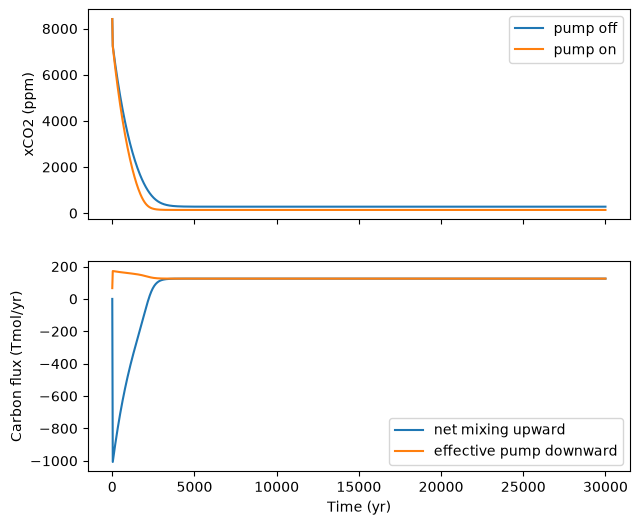

Matched change in deep carbon (Pmol): 42.736853008451945
Actual stationary export (Tmol/yr): 125.29182825674133


In [6]:
# Understand and run: trace this supplied step and interpret its evidence.
pump_on = build_layers(k)
run_model(pump_on)
print(audit(pump_on))
for label, case in [('pump off', pump_off), ('pump on', pump_on)]:
    print(label, 'xCO2 (ppm), surface/deep DIC (umol/kg):',
          case.CO2_At.c[-1] * 1e6, case.Surface.DIC.c[-1] * 1e6,
          case.Deep.DIC.c[-1] * 1e6)
np.testing.assert_allclose(pump_on.Deep.DIC.c[-1] / pump_on.Surface.DIC.c[-1],
                           config.target_deep_dic_umol_kg / config.target_dic_umol_kg, rtol=1e-4)
Jmix = mixing_mass_transport() * (pump_on.Deep.DIC.c - pump_on.Surface.DIC.c)
Jpump = k * pump_on.Surface.DIC.c
np.testing.assert_allclose(Jmix[-1], Jpump[-1], rtol=1e-4)
plot_pump_comparison(pump_off, pump_on, Jmix, Jpump)
deep_transfer = box_mass_kg(pump_on.Deep) * (pump_on.Deep.DIC.c[-1] - pump_off.Deep.DIC.c[-1])
print('Matched change in deep carbon (Pmol):', deep_transfer / 1e15)
print('Actual stationary export (Tmol/yr):', Jpump[-1] / 1e12)

### B4. Interpret the pump-on/pump-off comparison

The two runs start with the same carbon and TA inventories; only the pump
changes. A **conditional model result** is an output that follows from these
chosen inputs and assumptions.

<div style="background-color: #edf5ff; color: #173b61; border-left: 4px solid #3977b8; padding: 12px 16px; margin: 16px 0; border-radius: 4px;">

**Question — interpret the matched experiment**

Which result was fitted? Which outputs are <mark style="background-color: #fff0b3; color: #513d00; padding: 0.05em 0.2em; border-radius: 3px;"><strong>conditional model results</strong></mark>? Identify
the early gas-exchange adjustment and the slower approach of net upward mixing
and downward pump fluxes to equality. Why does fitting the DIC ratio not require the final atmosphere to be 280 ppm?

</div>

<!-- BEGIN SOLUTION -->
<div style="background-color: #f3eefb; color: #38224f; border-left: 4px solid #7952a8; padding: 12px 16px; margin: 16px 0; border-radius: 4px;">

**Instructor answer**

The stationary DIC ratio was fitted. Atmospheric xCO2, absolute surface/deep
DIC, carbon transferred and adjustment timescale follow conditionally from
the closure, inventory and chemistry. The deep balance fixes a ratio, not the
atmosphere. At fixed 01 carbon inventory the pump lowers surface DIC and xCO2.
The 01 calibration also used observed xCO2/DIC, so these are not independent
observational validations. Matching the fitted ratio only checks implementation.

</div>
<!-- END SOLUTION -->

## C. Calculate a carbon input and verify the forced run

Part B kept the original 01 carbon inventory. Now calculate the additional
carbon needed to reach the **full reference state**: 280 ppm in the atmosphere,
2040 µmol/kg DIC at the surface and 2250 µmol/kg at depth.

At that reference state, the prepared geometry gives an ocean/atmosphere
<mark style="background-color: #fff0b3; color: #513d00; padding: 0.05em 0.2em; border-radius: 3px;"><strong>inventory ratio</strong></mark> of **62.4**, meaning 62.4 moles of ocean carbon per mole
of atmospheric carbon. This compares whole-reservoir inventories; it is not
the seawater equilibrium capacity $F$ discussed in the lecture.

### C1. Derive and calculate the required addition

<div style="background-color: #edf5ff; color: #173b61; border-left: 4px solid #3977b8; padding: 12px 16px; margin: 16px 0; border-radius: 4px;">

**Question — derive the carbon addition**

Before running any forcing, use the following inputs to calculate how much
extra carbon would make that reference pumped state possible:

| Input | Where to find it |
| --- | --- |
| Pumped ocean/atmosphere carbon ratio, 62.4 | `config.pumped_ocean_atmosphere_ratio` |
| Reference atmospheric xCO2, 280 ppm | `config.target_xco2_ppm` |
| Total atmospheric gas inventory (mol) | `config.atmosphere_mol` |
| Existing atmosphere-plus-ocean carbon (mol C) | `config.total_carbon_mol` |

1. Convert the reference atmospheric mole fraction into moles of atmospheric carbon.
2. Use 62.4 to calculate the ocean carbon and then the combined target inventory.
3. Subtract the existing total carbon to find the extra carbon to inject. Use
   the actual inventory; do not substitute a rounded baseline ratio of 57.
4. Check your answer against the extra carbon held in the deep box relative to
   a uniform ocean at the reference surface DIC. Explain why the two expressions agree.
5. In **02.4**, assign the atmospheric reference inventory to `C_atm_280`, the
   combined target to `target_total_carbon`, and the addition in **mol C** to
   `extra_carbon_mol`. The supplied forcing uses the addition as its `mass`.

Predict the endpoint before running the model. The geometry, inferred TA and
fitted pump already make the reference state consistent; recovering it tests
the forcing implementation and conservation.

</div>

<!-- BEGIN SOLUTION -->
<div style="background-color: #f3eefb; color: #38224f; border-left: 4px solid #7952a8; padding: 12px 16px; margin: 16px 0; border-radius: 4px;">

**Instructor answer**

Let $C_{atm,280}=N_{atm}(280\times10^{-6})$ and let $C_0$ denote the existing
combined inventory. The required addition is

$$\Delta C=(1+62.4)C_{atm,280}-C_0.$$

Equivalently, calculate the actual unpumped ocean/atmosphere ratio
$R_0=(C_0-C_{atm,280})/C_{atm,280}$ and use
$\Delta C=(62.4-R_0)C_{atm,280}$. With the default inputs, $R_0\simeq56.9998256$;
using exactly 57 introduces a small rounding mismatch.

Because the prepared volumes sum to the 01 ocean volume, subtracting the two
reference ocean inventories also gives

$$\Delta C=m_d(DIC_d^*-DIC_s^*).$$

These expressions yield about 267.6326 Pmol C. The atmospheric reference
inventory is included in both total inventories and cancels in the difference.

</div>
<!-- END SOLUTION -->

In [11]:
# Choose and explain: complete marked choices; surrounding machinery is supplied.
# Exercise 02.4: evaluate your derived carbon addition in mol C.
# Assign C_atm_280, target_total_carbon and extra_carbon_mol.
# BEGIN SOLUTION
C_atm_280 = config.atmosphere_mol * config.target_xco2_ppm * 1e-6
target_total_carbon = (1 + config.pumped_ocean_atmosphere_ratio) * C_atm_280
extra_carbon_mol = target_total_carbon - config.total_carbon_mol
# END SOLUTION
print('Carbon to inject (Pmol C):', extra_carbon_mol / 1e15)

Carbon to inject (Pmol C): 267.63264476779057


In [12]:
# BEGIN SOLUTION
# Supplied independent algebraic check of the same prepared reference inventory.
extra_carbon_from_boxes = box_mass_kg(pump_on.Deep) * (
    config.target_deep_dic_umol_kg - config.target_dic_umol_kg) * 1e-6
np.testing.assert_allclose(extra_carbon_mol, extra_carbon_from_boxes, rtol=1e-12)
print('Actual baseline ocean/atmosphere ratio:',
      (config.total_carbon_mol - C_atm_280) / C_atm_280)
# END SOLUTION

Actual baseline ocean/atmosphere ratio: 56.99982556965717


### C2. Run the supplied forcing and budget checks

A **restart** uses the final concentrations from a previous run as the initial
state of a new run. Here both new runs start from the Part B pump-on endpoint.
The **control** receives no input; the **forced run** receives your extra carbon
through the atmosphere. Their difference isolates the response to that input.

`Signal` prescribes the carbon flux over time. Its `mass` is the total addition,
not a flux rate. The square pulse starts at 1000 yr and lasts 1000 yr; `Source`
represents carbon outside the model, connected to the atmospheric reservoir by
`Species2Species`.

Read the supplied checks in this order:

1. **Input:** both the sum of sampled fluxes times the time step and the integral
   of the solver's interpolated flux equal your intended addition. The solver
   joins successive samples with straight lines. The pulse is zero at the start
   and end of the simulation.
2. **Budget:** total carbon increases by the cumulative input, while total TA
   stays constant. `audit(forced, added)` checks this throughout the run.
3. **Endpoint:** compare the final atmosphere and both DIC concentrations with
   the reference state. This is a consistency check of the constructed model.



ESBMTK 0.14.3.1.post0  
 Copyright (C) 2020 - 2026  Ulrich G.Wortmann
This program comes with ABSOLUTELY NO WARRANTY
This is free software, and you are welcome to redistribute it
under certain conditions; See the LICENSE file for details.

If you use ESBMTK for your research, please cite:

Wortmann et al. 2025, https://doi.org/10.5194/gmd-18-1155-2025


ESBMTK 0.14.3.1.post0  
 Copyright (C) 2020 - 2026  Ulrich G.Wortmann
This program comes with ABSOLUTELY NO WARRANTY
This is free software, and you are welcome to redistribute it
under certain conditions; See the LICENSE file for details.

If you use ESBMTK for your research, please cite:

Wortmann et al. 2025, https://doi.org/10.5194/gmd-18-1155-2025

status=0
message=The solver successfully reached the end of the integration interval.


 Execution took 1.36 CPU seconds, wall time = 1.38 seconds

status=0
message=The solver successfully reached the end of the integration interval.


 Execution took 0.55 CPU seconds, wall time = 0.54 s

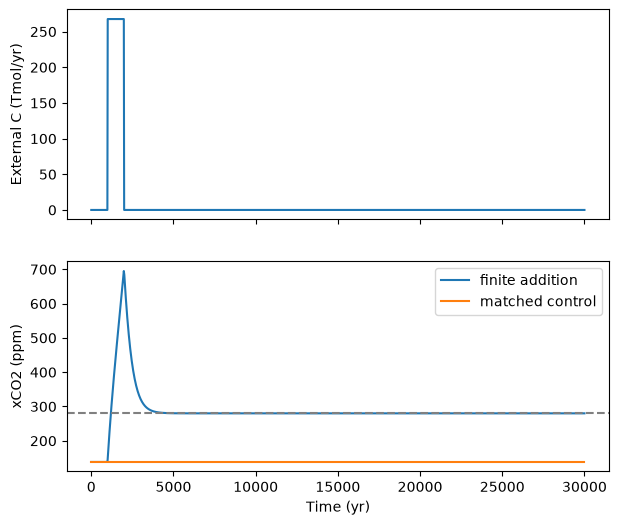

Final departure from 280 ppm: 3.6782695360670914e-06


In [17]:
# Understand and run: trace this supplied step and interpret its evidence.
# Supplied forcing example: insert your calculated extra_carbon_mol above.
state = {b.name: (b.DIC.c[-1] * 1e6, b.TA.c[-1] * 1e6) for b in pump_on.ocean_boxes}
forced = build_layers(k, state=state)
control = build_layers(k, state=state)
# Recompute atmospheric carbon by conservation from the pump-on restart.
np.testing.assert_allclose(forced.CO2_At.c[0], pump_on.CO2_At.c[-1], atol=1e-10)

signal = Signal(name='synthetic_carbon', species=forced.CO2, register=forced,
                start='1000 yr', duration='1000 yr',
                mass=f'{extra_carbon_mol} mol', shape='square')
source = Source(name='external_carbon', species=forced.CO2)
connection = Species2Species(source=source, sink=forced.CO2_At,
                            rate='0 mol/yr', signal=signal, id='synthetic_input')
signal_time, signal_flux = forced.time.copy(), signal.m.copy()
sampled_mass = signal_flux.sum() * forced.dt
continuous_mass = integrated_signal(signal_time, signal_flux, signal_time[-1])
np.testing.assert_allclose([sampled_mass, continuous_mass], extra_carbon_mol, rtol=1e-12)
for case in (control, forced):
    run_model(case)
added = integrated_signal(signal_time, signal_flux, forced.time)
print('Control budget:', audit(control))
print('Forced budget:', audit(forced, added))
np.testing.assert_allclose(forced.CO2_At.c[-1] * 1e6, 280, atol=0.5)
np.testing.assert_allclose(forced.Surface.DIC.c[-1] * 1e6, 2040, atol=0.2)
np.testing.assert_allclose(forced.Deep.DIC.c[-1] * 1e6, 2250, atol=0.2)
plot_synthetic_forcing(signal_time, signal_flux, forced, control)
print('Final departure from 280 ppm:', forced.CO2_At.c[-1] * 1e6 - 280)

### C3. Explain what the forcing experiment establishes

<div style="background-color: #edf5ff; color: #173b61; border-left: 4px solid #3977b8; padding: 12px 16px; margin: 16px 0; border-radius: 4px;">

**Question — explain the forcing check**

Explain why 62.4 and the mass-based initial inventory lead to the carbon amount
you used. Why should this implementation check return close to 280 ppm? If it
does not, inspect signal units, its integrated mass, carbon/TA conservation,
equilibration and chemistry settings before changing any model inputs.

</div>

<!-- BEGIN SOLUTION -->
<div style="background-color: #f3eefb; color: #38224f; border-left: 4px solid #7952a8; padding: 12px 16px; margin: 16px 0; border-radius: 4px;">

**Instructor answer**

The total reference inventory is the sum of the target ocean and atmospheric
carbon. Subtracting the existing combined inventory gives exactly the required
external input. The prepared geometry, target-derived TA and inferred pump
coefficient make this state internally consistent. Returning there verifies
the forcing implementation and analytical carbon budget; it is not independent
validation of the effective pump. A different addition generally gives a
different atmospheric endpoint through nonlinear carbonate chemistry.

</div>
<!-- END SOLUTION -->

The native solver may flag pH changes between stored output points during these
large transients. Use the explicit inventories, stationary flux balance and
endpoint checks above; transient pH interpretation is outside this practical.

<div style="background-color: #edf5ff; color: #173b61; border-left: 4px solid #3977b8; padding: 12px 16px; margin: 16px 0; border-radius: 4px;">

**Question — final synthesis**

**Finish 02:** submit your two derivations (including units) and one sentence
distinguishing the fitted DIC ratio from the conditional atmospheric response.
Point to one internal arrow and the external forcing arrow in your code.

</div>